# Construction Project Delay Risk Prediction

## Project Context

This project aims to predict the risk of delay in construction projects using machine learning.

The dataset used in this project is synthetic and inspired by real-world project management challenges in the construction and public works sector.

The objective is to support project managers in identifying projects that are more likely to experience delays based on planning, budget, resources, material availability, equipment availability, weather risk, supplier delays, project complexity and safety incidents.


## 1. Importing Required Libraries

In this section, we import the Python libraries required for data manipulation, numerical computation and visualization.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully")


Libraries imported successfully


## 2. Synthetic Dataset Generation

Since real construction project data is not publicly available, this project uses a synthetic dataset inspired by real-world construction and public works project management.

The generated dataset includes project characteristics such as project type, region, planned duration, progress, budget, resource availability, supplier delays, weather risk, project complexity and safety incidents.

In [16]:
# Set random seed for reproducibility
np.random.seed(42)

# Number of synthetic construction projects
n_projects = 1000

# Possible categories
project_types = ["Road", "Building", "Bridge", "Pipeline", "Housing", "Industrial Site"]
regions = [
    "Alger", "Oran", "Constantine", "Setif", "Blida", "Ouargla",
    "Tlemcen", "Annaba", "Bejaia", "Djelfa", "Batna", "Mostaganem"
]

availability_levels = ["Low", "Medium", "High"]
risk_levels = ["Low", "Medium", "High"]
complexity_levels = ["Low", "Medium", "High"]

# Generate synthetic features
data = pd.DataFrame({
    "Project_ID": [f"PRJ_{i:04d}" for i in range(1, n_projects + 1)],
    
    "Project_Type": np.random.choice(
        project_types, 
        size=n_projects, 
        p=[0.22, 0.20, 0.13, 0.17, 0.18, 0.10]
    ),
    
    "Region": np.random.choice(regions, size=n_projects),
    
    "Planned_Duration_Months": np.random.randint(6, 49, size=n_projects),
    
    "Project_Progress_Percent": np.random.randint(5, 101, size=n_projects),
    
    "Budget_Million_DZD": np.round(
        np.random.uniform(50, 5000, size=n_projects), 
        2
    ),
    
    "Cost_Used_Percent": np.round(
        np.random.uniform(10, 130, size=n_projects), 
        2
    ),
    
    "Number_of_Workers": np.random.randint(20, 800, size=n_projects),
    
    "Material_Availability": np.random.choice(
        availability_levels, 
        size=n_projects, 
        p=[0.25, 0.45, 0.30]
    ),
    
    "Equipment_Availability": np.random.choice(
        availability_levels, 
        size=n_projects, 
        p=[0.20, 0.50, 0.30]
    ),
    
    "Weather_Risk": np.random.choice(
        risk_levels, 
        size=n_projects, 
        p=[0.45, 0.35, 0.20]
    ),
    
    "Supplier_Delay": np.random.choice(
        ["No", "Yes"], 
        size=n_projects, 
        p=[0.70, 0.30]
    ),
    
    "Project_Complexity": np.random.choice(
        complexity_levels, 
        size=n_projects, 
        p=[0.35, 0.45, 0.20]
    ),
    
    "Safety_Incidents": np.random.poisson(lam=1.2, size=n_projects)
})

# Create a realistic delay risk score
risk_score = (
    (data["Material_Availability"] == "Low") * 2.0 +
    (data["Equipment_Availability"] == "Low") * 1.8 +
    (data["Weather_Risk"] == "High") * 1.5 +
    (data["Supplier_Delay"] == "Yes") * 2.2 +
    (data["Project_Complexity"] == "High") * 1.7 +
    (data["Cost_Used_Percent"] > 100) * 1.5 +
    (data["Project_Progress_Percent"] < 40) * 1.2 +
    (data["Safety_Incidents"] >= 3) * 1.0 +
    (data["Planned_Duration_Months"] > 30) * 0.8
)

# Add random noise
risk_score = risk_score + np.random.normal(0, 1, n_projects)

# Convert risk score to probability
delay_probability = 1 / (1 + np.exp(-risk_score + 4))

# Generate target variable
data["Delay_Risk"] = np.where(
    np.random.rand(n_projects) < delay_probability,
    "Yes",
    "No"
)

# Display first rows
data.head()

,Project_ID,Project_Type,Region,Planned_Duration_Months,Project_Progress_Percent,Budget_Million_DZD,Cost_Used_Percent,Number_of_Workers,Material_Availability,Equipment_Availability,Weather_Risk,Supplier_Delay,Project_Complexity,Safety_Incidents,Delay_Risk
0,PRJ_0001,Building,Mostaganem,17,68,4684.52,94.17,44,Medium,High,Medium,No,Medium,1,No
1,PRJ_0002,Industrial Site,Annaba,47,95,2732.85,23.61,757,Low,High,Low,No,Medium,1,No
2,PRJ_0003,Housing,Constantine,43,55,4701.27,129.63,76,Medium,Medium,High,No,Medium,1,Yes
3,PRJ_0004,Pipeline,Annaba,23,54,1141.39,32.01,199,Medium,High,High,Yes,High,1,No
4,PRJ_0005,Road,Blida,40,10,3642.34,81.30,251,Low,High,Low,No,Medium,1,Yes


## 3. First Look at the Dataset

This section provides a first overview of the generated dataset, including its shape, column names and first observations.

In [17]:
# Dataset shape
print("Dataset shape:", data.shape)

# Column names
print("\nColumns:")
print(data.columns.tolist())

# First rows
data.head()

Dataset shape: (1000, 15)

Columns:
['Project_ID', 'Project_Type', 'Region', 'Planned_Duration_Months', 'Project_Progress_Percent', 'Budget_Million_DZD', 'Cost_Used_Percent', 'Number_of_Workers', 'Material_Availability', 'Equipment_Availability', 'Weather_Risk', 'Supplier_Delay', 'Project_Complexity', 'Safety_Incidents', 'Delay_Risk']


,Project_ID,Project_Type,Region,Planned_Duration_Months,Project_Progress_Percent,Budget_Million_DZD,Cost_Used_Percent,Number_of_Workers,Material_Availability,Equipment_Availability,Weather_Risk,Supplier_Delay,Project_Complexity,Safety_Incidents,Delay_Risk
0,PRJ_0001,Building,Mostaganem,17,68,4684.52,94.17,44,Medium,High,Medium,No,Medium,1,No
1,PRJ_0002,Industrial Site,Annaba,47,95,2732.85,23.61,757,Low,High,Low,No,Medium,1,No
2,PRJ_0003,Housing,Constantine,43,55,4701.27,129.63,76,Medium,Medium,High,No,Medium,1,Yes
3,PRJ_0004,Pipeline,Annaba,23,54,1141.39,32.01,199,Medium,High,High,Yes,High,1,No
4,PRJ_0005,Road,Blida,40,10,3642.34,81.30,251,Low,High,Low,No,Medium,1,Yes


## 4. Target Variable Distribution

The target variable is `Delay_Risk`, which indicates whether a construction project is at risk of delay or not.

This section checks the number and percentage of projects classified as delayed-risk projects.

In [18]:
# Target variable distribution
delay_counts = data["Delay_Risk"].value_counts()
delay_percentages = data["Delay_Risk"].value_counts(normalize=True) * 100

print("Delay Risk Counts:")
print(delay_counts)

print("\nDelay Risk Percentages:")
print(delay_percentages.round(2))

Delay Risk Counts:
Delay_Risk
No     597
Yes    403
Name: count, dtype: int64

Delay Risk Percentages:
Delay_Risk
No     59.7
Yes    40.3
Name: proportion, dtype: float64


## 5. Saving the Synthetic Dataset

The generated dataset is saved as a CSV file in the `data` folder so that it can be reused for the rest of the analysis and uploaded to GitHub.

In [19]:
# Save the synthetic dataset
output_path = "../data/synthetic_construction_projects.csv"

data.to_csv(output_path, index=False, encoding="utf-8")

print(f"Dataset saved successfully at: {output_path}")

Dataset saved successfully at: ../data/synthetic_construction_projects.csv


## 6. General Dataset Information

This section provides general information about the dataset, including the number of rows, columns, data types and non-null values.

In [20]:
# General information about the dataset
print("Dataset shape:", data.shape)

print("\nDataset information:")
data.info()

Dataset shape: (1000, 15)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Project_ID                1000 non-null   object 
 1   Project_Type              1000 non-null   object 
 2   Region                    1000 non-null   object 
 3   Planned_Duration_Months   1000 non-null   int32  
 4   Project_Progress_Percent  1000 non-null   int32  
 5   Budget_Million_DZD        1000 non-null   float64
 6   Cost_Used_Percent         1000 non-null   float64
 7   Number_of_Workers         1000 non-null   int32  
 8   Material_Availability     1000 non-null   object 
 9   Equipment_Availability    1000 non-null   object 
 10  Weather_Risk              1000 non-null   object 
 11  Supplier_Delay            1000 non-null   object 
 12  Project_Complexity        1000 non-null   object 
 13  Safety_Incidents

## 7. Descriptive Statistics

This section presents descriptive statistics for numerical variables such as planned duration, progress percentage, budget, cost used percentage, number of workers and safety incidents.

In [21]:
# Descriptive statistics for numerical variables
data.describe()

,Planned_Duration_Months,Project_Progress_Percent,Budget_Million_DZD,Cost_Used_Percent,Number_of_Workers,Safety_Incidents
count,1000.000000,1000.0000,1000.000000,1000.000000,1000.00000,1000.00000
mean,27.083000,52.7100,2537.092400,69.494860,402.15200,1.19700
std,12.222172,27.4413,1409.982201,34.520953,222.32943,1.09608
min,6.000000,5.0000,56.660000,10.020000,20.00000,0.00000
25%,17.000000,29.0000,1332.537500,40.287500,213.00000,0.00000
50%,27.000000,53.0000,2576.255000,69.505000,400.00000,1.00000
75%,38.000000,76.0000,3769.967500,99.407500,595.00000,2.00000
max,48.000000,100.0000,4988.230000,129.630000,799.00000,7.00000


## 8. Missing Values Analysis

Before building any machine learning model, it is important to check whether the dataset contains missing values.

In [22]:
# Check missing values
data.isnull().sum()

Project_ID                  0
Project_Type                0
Region                      0
Planned_Duration_Months     0
Project_Progress_Percent    0
Budget_Million_DZD          0
Cost_Used_Percent           0
Number_of_Workers           0
Material_Availability       0
Equipment_Availability      0
Weather_Risk                0
Supplier_Delay              0
Project_Complexity          0
Safety_Incidents            0
Delay_Risk                  0
dtype: int64

## 9. Delay Risk Distribution

This section analyzes the distribution of the target variable `Delay_Risk`.

It helps us understand whether the dataset is balanced or imbalanced between delayed-risk and non-delayed-risk projects.

In [23]:
# Distribution of the target variable
delay_counts = data["Delay_Risk"].value_counts()
delay_percentages = data["Delay_Risk"].value_counts(normalize=True) * 100

print("Delay Risk Counts:")
print(delay_counts)

print("\nDelay Risk Percentages:")
print(delay_percentages.round(2))

Delay Risk Counts:
Delay_Risk
No     597
Yes    403
Name: count, dtype: int64

Delay Risk Percentages:
Delay_Risk
No     59.7
Yes    40.3
Name: proportion, dtype: float64


## 10. Visualization of Delay Risk Distribution

This chart shows the number of projects classified as having delay risk versus those without delay risk.

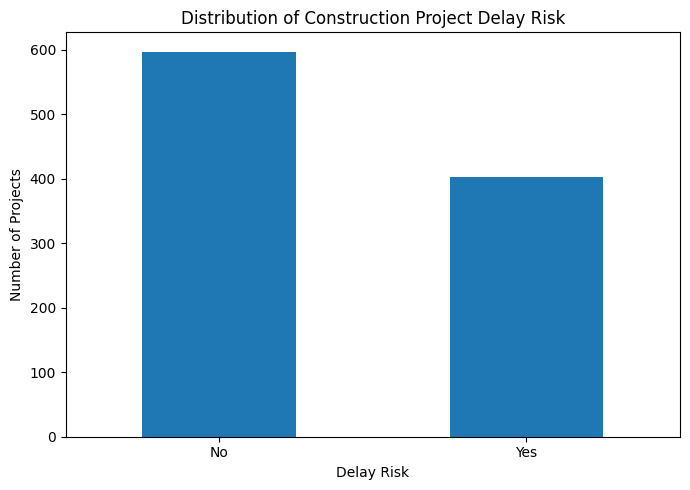

In [24]:
# Plot target variable distribution
plt.figure(figsize=(7, 5))
data["Delay_Risk"].value_counts().plot(kind="bar")

plt.title("Distribution of Construction Project Delay Risk")
plt.xlabel("Delay Risk")
plt.ylabel("Number of Projects")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../figures/delay_risk_distribution.png")
plt.show()

## 11. Delay Risk by Project Type

This section analyzes whether some types of construction projects are more exposed to delay risk than others.

Project_Type
Bridge             0.454545
Pipeline           0.437870
Road               0.407563
Industrial Site    0.390000
Building           0.385000
Housing            0.354651
Name: Delay_Risk, dtype: float64


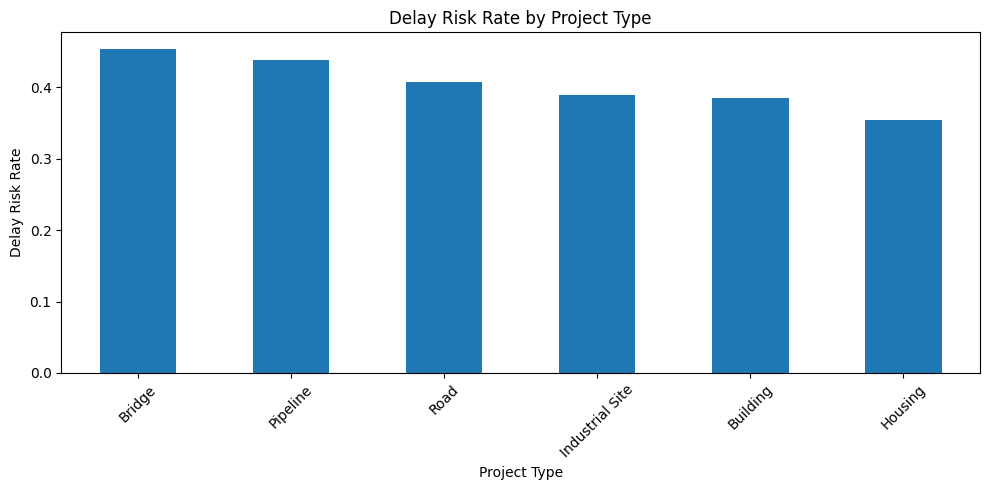

In [25]:
# Delay rate by project type
delay_by_type = data.groupby("Project_Type")["Delay_Risk"].apply(
    lambda x: (x == "Yes").mean()
).sort_values(ascending=False)

print(delay_by_type)

plt.figure(figsize=(10, 5))
delay_by_type.plot(kind="bar")

plt.title("Delay Risk Rate by Project Type")
plt.xlabel("Project Type")
plt.ylabel("Delay Risk Rate")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../figures/delay_by_project_type.png")
plt.show()

## 12. Delay Risk by Material Availability

Material availability is a key factor in construction project execution.

This section analyzes how the level of material availability is associated with project delay risk.

Material_Availability
Low       0.618110
Medium    0.333333
High      0.324138
Name: Delay_Risk, dtype: float64


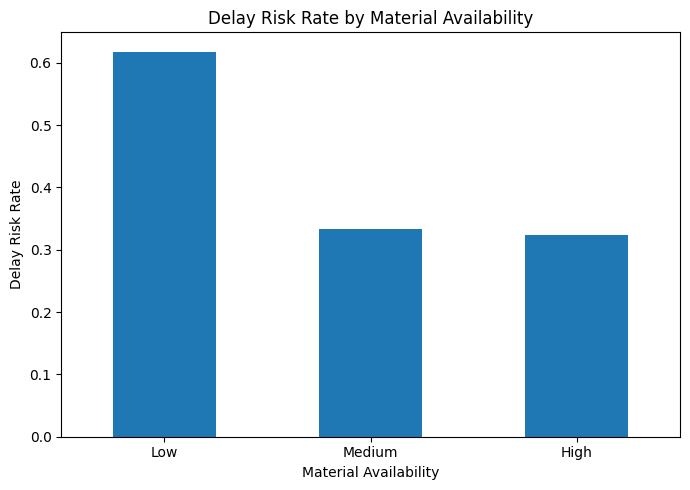

In [26]:
# Delay rate by material availability
delay_by_material = data.groupby("Material_Availability")["Delay_Risk"].apply(
    lambda x: (x == "Yes").mean()
).sort_values(ascending=False)

print(delay_by_material)

plt.figure(figsize=(7, 5))
delay_by_material.plot(kind="bar")

plt.title("Delay Risk Rate by Material Availability")
plt.xlabel("Material Availability")
plt.ylabel("Delay Risk Rate")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../figures/delay_by_material_availability.png")
plt.show()

## 13. Delay Risk by Equipment Availability

Equipment availability is another important operational factor.

This section evaluates whether low equipment availability is associated with a higher risk of project delay.

Equipment_Availability
Low       0.589109
Medium    0.357895
High      0.352941
Name: Delay_Risk, dtype: float64


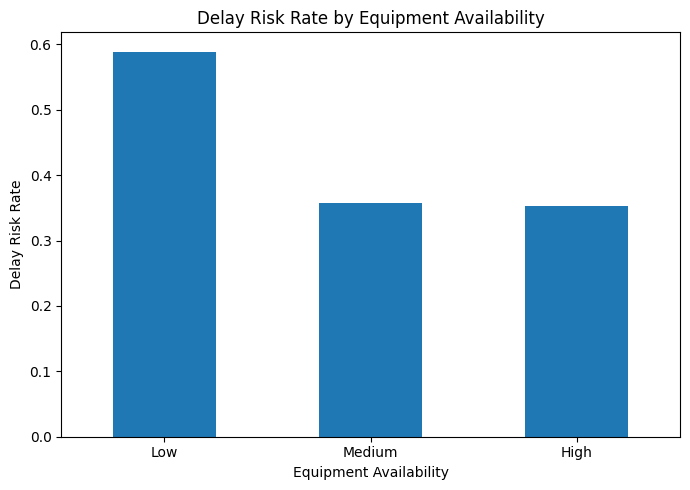

In [27]:
# Delay rate by equipment availability
delay_by_equipment = data.groupby("Equipment_Availability")["Delay_Risk"].apply(
    lambda x: (x == "Yes").mean()
).sort_values(ascending=False)

print(delay_by_equipment)

plt.figure(figsize=(7, 5))
delay_by_equipment.plot(kind="bar")

plt.title("Delay Risk Rate by Equipment Availability")
plt.xlabel("Equipment Availability")
plt.ylabel("Delay Risk Rate")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../figures/delay_by_equipment_availability.png")
plt.show()

## 14. Delay Risk by Supplier Delay

Supplier delays can directly affect project execution and planning.

This section compares the delay risk rate between projects with and without supplier delays.

Supplier_Delay
Yes    0.625442
No     0.315202
Name: Delay_Risk, dtype: float64


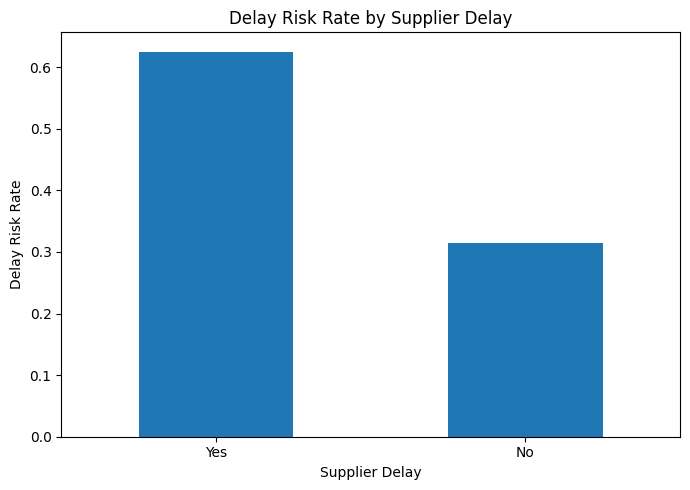

In [28]:
# Delay rate by supplier delay
delay_by_supplier = data.groupby("Supplier_Delay")["Delay_Risk"].apply(
    lambda x: (x == "Yes").mean()
).sort_values(ascending=False)

print(delay_by_supplier)

plt.figure(figsize=(7, 5))
delay_by_supplier.plot(kind="bar")

plt.title("Delay Risk Rate by Supplier Delay")
plt.xlabel("Supplier Delay")
plt.ylabel("Delay Risk Rate")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../figures/delay_by_supplier_delay.png")
plt.show()

## 15. Cost Used Percentage by Delay Risk

Budget consumption is an important indicator in project monitoring.

This boxplot compares the percentage of budget already used between projects with delay risk and projects without delay risk.

<Figure size 700x500 with 0 Axes>

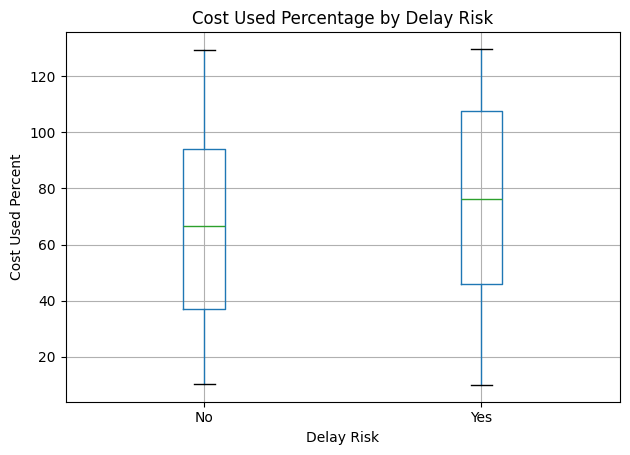

In [29]:
# Cost used percentage by delay risk
plt.figure(figsize=(7, 5))

data.boxplot(
    column="Cost_Used_Percent",
    by="Delay_Risk"
)

plt.title("Cost Used Percentage by Delay Risk")
plt.suptitle("")
plt.xlabel("Delay Risk")
plt.ylabel("Cost Used Percent")
plt.tight_layout()

plt.savefig("../figures/cost_used_by_delay_risk.png")
plt.show()

## 16. Exploratory Data Analysis Summary

The exploratory analysis shows that approximately 40% of the synthetic construction projects are classified as having delay risk.

The results suggest that delay risk is higher for infrastructure-related projects such as bridges, pipelines and roads.

Material availability, equipment availability and supplier delays appear to be strongly associated with project delay risk. Projects with low material availability, low equipment availability or supplier delays show a much higher probability of delay.

The boxplot also indicates that projects with delay risk tend to have higher budget consumption levels, suggesting that cost overrun indicators may be useful for early delay detection.

These findings are consistent with real-world project management challenges in the construction and public works sector.

## 17. Preparing Data for Machine Learning

In this section, the dataset is prepared for machine learning.

The target variable `Delay_Risk` is converted into a binary variable:

- `No` is encoded as 0
- `Yes` is encoded as 1

The project identifier is removed because it does not provide predictive information.

The dataset is then split into explanatory variables `X` and target variable `y`.

In [30]:
# Create a copy of the dataset for machine learning
data_ml = data.copy()

# Encode target variable
data_ml["Delay_Risk"] = data_ml["Delay_Risk"].map({
    "No": 0,
    "Yes": 1
})

# Define features and target
X = data_ml.drop(columns=["Project_ID", "Delay_Risk"])
y = data_ml["Delay_Risk"]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

X.head()

Shape of X: (1000, 13)
Shape of y: (1000,)


,Project_Type,Region,Planned_Duration_Months,Project_Progress_Percent,Budget_Million_DZD,Cost_Used_Percent,Number_of_Workers,Material_Availability,Equipment_Availability,Weather_Risk,Supplier_Delay,Project_Complexity,Safety_Incidents
0,Building,Mostaganem,17,68,4684.52,94.17,44,Medium,High,Medium,No,Medium,1
1,Industrial Site,Annaba,47,95,2732.85,23.61,757,Low,High,Low,No,Medium,1
2,Housing,Constantine,43,55,4701.27,129.63,76,Medium,Medium,High,No,Medium,1
3,Pipeline,Annaba,23,54,1141.39,32.01,199,Medium,High,High,Yes,High,1
4,Road,Blida,40,10,3642.34,81.30,251,Low,High,Low,No,Medium,1


## 18. Identifying Numerical and Categorical Features

Machine learning models require numerical inputs.

Numerical variables will be scaled, while categorical variables will be transformed using one-hot encoding.

In [31]:
# Identify numerical and categorical features
numerical_features = X.select_dtypes(include=["int64", "int32", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Planned_Duration_Months', 'Project_Progress_Percent', 'Budget_Million_DZD', 'Cost_Used_Percent', 'Number_of_Workers', 'Safety_Incidents']

Categorical features:
['Project_Type', 'Region', 'Material_Availability', 'Equipment_Availability', 'Weather_Risk', 'Supplier_Delay', 'Project_Complexity']


## 19. Train-Test Split

The dataset is split into training and testing sets.

The training set is used to train the models, while the test set is used to evaluate their performance on unseen data.

A stratified split is used to preserve the same proportion of delay-risk projects in both training and test sets.

In [32]:
from sklearn.model_selection import train_test_split

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nDelay risk distribution in training set:")
print(y_train.value_counts(normalize=True).round(3) * 100)

print("\nDelay risk distribution in test set:")
print(y_test.value_counts(normalize=True).round(3) * 100)

X_train shape: (800, 13)
X_test shape: (200, 13)
y_train shape: (800,)
y_test shape: (200,)

Delay risk distribution in training set:
Delay_Risk
0    59.8
1    40.2
Name: proportion, dtype: float64

Delay risk distribution in test set:
Delay_Risk
0    59.5
1    40.5
Name: proportion, dtype: float64


## 20. Preprocessing Pipeline

A preprocessing pipeline is created to prepare the data before model training.

The preprocessing includes:

- standardization of numerical variables;
- one-hot encoding of categorical variables.

This ensures that the same transformations are applied consistently to training and test data.

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessor created successfully")

Preprocessor created successfully


## 21. Model Training and Evaluation

In this section, several machine learning classification models are trained and evaluated.

The objective is to compare their performance in predicting construction project delay risk.

The models used are:

- Logistic Regression
- Random Forest
- Gradient Boosting

The evaluation metrics include:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Machine learning libraries imported successfully")

Machine learning libraries imported successfully


## 22. Defining Machine Learning Models

Each model is combined with the preprocessing pipeline.

This ensures that numerical and categorical variables are properly transformed before model training.

In [35]:
# Define machine learning models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

print("Models defined successfully")

Models defined successfully


## 23. Training and Comparing Models

The models are trained on the training set and evaluated on the test set.

The results are stored in a comparison table to identify the best-performing model.

In [36]:
# Train and evaluate models
results = []

trained_models = {}

for model_name, model in models.items():
    
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )
    
    # Train model
    pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    # Evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": roc_auc
    })
    
    trained_models[model_name] = pipeline

# Create results dataframe
results_df = pd.DataFrame(results)

# Sort by ROC-AUC
results_df = results_df.sort_values(by="ROC-AUC", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.720,0.658228,0.641975,0.650000,0.806100
2,Gradient Boosting,0.715,0.671429,0.580247,0.622517,0.792406
1,Random Forest,0.725,0.685714,0.592593,0.635762,0.791939


## 24. Saving Model Results

The model comparison results are saved as a CSV file for documentation and GitHub presentation.

In [37]:
# Save model results
results_df.to_csv("../model_results.csv", index=False)

print("Model results saved successfully")

Model results saved successfully


## 25. Selecting the Best Model

The best model is selected based on ROC-AUC, which measures the model's ability to distinguish between projects with delay risk and projects without delay risk.

In [38]:
# Select best model based on ROC-AUC
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best model based on ROC-AUC:", best_model_name)

Best model based on ROC-AUC: Logistic Regression


## 26. Detailed Evaluation of the Best Model

The best model selected based on ROC-AUC is evaluated in more detail.

This section includes:

- confusion matrix;
- classification report;
- ROC curve.

These elements help understand the model's predictive performance beyond global metrics.

In [39]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Predictions using the best model
y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully")

Predictions generated successfully


## 27. Confusion Matrix

The confusion matrix shows how many projects were correctly or incorrectly classified.

It compares actual delay-risk labels with predicted labels.

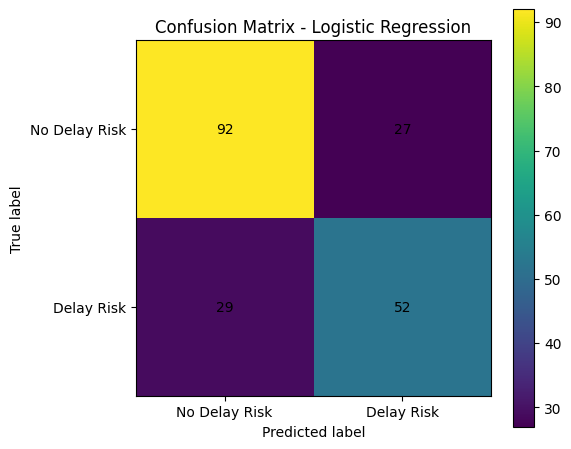

In [40]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.xticks([0, 1], ["No Delay Risk", "Delay Risk"])
plt.yticks([0, 1], ["No Delay Risk", "Delay Risk"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()

plt.savefig("../figures/confusion_matrix.png")
plt.show()

## 28. Classification Report

The classification report provides precision, recall and F1-score for each class.

This is useful because the project is not only about global accuracy, but also about correctly detecting projects with delay risk.

In [41]:
# Classification report
print(f"Classification Report for {best_model_name}")
print(classification_report(
    y_test,
    y_pred_best,
    target_names=["No Delay Risk", "Delay Risk"]
))

Classification Report for Logistic Regression
               precision    recall  f1-score   support

No Delay Risk       0.76      0.77      0.77       119
   Delay Risk       0.66      0.64      0.65        81

     accuracy                           0.72       200
    macro avg       0.71      0.71      0.71       200
 weighted avg       0.72      0.72      0.72       200



## 29. ROC Curve

The ROC curve shows the trade-off between the true positive rate and false positive rate.

A higher AUC value indicates a better ability to distinguish between projects with and without delay risk.

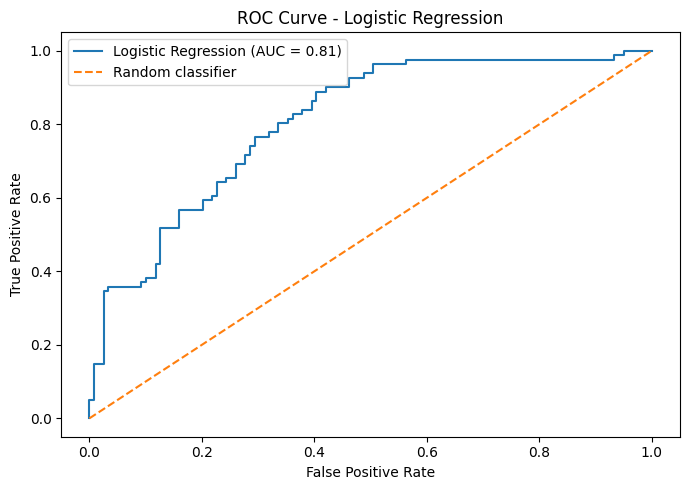

In [43]:
# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_best)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")

plt.title(f"ROC Curve - {best_model_name}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()

plt.savefig("../figures/roc_curve.png")
plt.show()

## 30. Model Evaluation Summary

The detailed evaluation provides a better understanding of the selected model.

The confusion matrix helps identify how many delay-risk projects were correctly detected, while the ROC curve confirms the model's ability to separate risky and non-risky projects.

In a construction management context, detecting delay-risk projects is important because early identification allows project managers to take preventive actions such as improving resource allocation, monitoring suppliers and controlling budget consumption.

## 31. Model Improvement: Decision Threshold Optimization

The initial Logistic Regression model uses a default classification threshold of 0.50.

In a construction project management context, detecting projects at risk of delay is very important. Missing a risky project can lead to delays, cost overruns and operational difficulties.

For this reason, this section tests different decision thresholds in order to improve the detection of delay-risk projects.

The objective is not only to maximize accuracy, but also to find a better balance between precision, recall and F1-score for the `Delay Risk` class.

In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Test different classification thresholds
thresholds = np.arange(0.20, 0.81, 0.05)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_proba_best >= threshold).astype(int)
    
    accuracy = accuracy_score(y_test, y_pred_threshold)
    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)
    
    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df

,Threshold,Accuracy,Precision,Recall,F1-score
0,0.20,0.685,0.565217,0.962963,0.712329
1,0.25,0.690,0.573643,0.913580,0.704762
2,0.30,0.705,0.598214,0.827160,0.694301
3,0.35,0.715,0.620000,0.765432,0.685083
4,0.40,0.720,0.634409,0.728395,0.678161
5,0.45,0.720,0.643678,0.691358,0.666667
6,0.50,0.720,0.658228,0.641975,0.650000
7,0.55,0.710,0.657534,0.592593,0.623377
8,0.60,0.725,0.703125,0.555556,0.620690
9,0.65,0.710,0.716981,0.469136,0.567164


## 32. Selecting the Best Threshold

The best threshold is selected based on the F1-score.

The F1-score provides a balance between precision and recall, which is useful when both false alarms and missed risky projects are important.

In [45]:
# Select threshold with the best F1-score
best_threshold = threshold_results_df.sort_values(
    by="F1-score",
    ascending=False
).iloc[0]["Threshold"]

print("Best threshold based on F1-score:", best_threshold)

# Predictions using the optimized threshold
y_pred_optimized = (y_proba_best >= best_threshold).astype(int)

print("\nClassification Report with Optimized Threshold")
print(classification_report(
    y_test,
    y_pred_optimized,
    target_names=["No Delay Risk", "Delay Risk"]
))

Best threshold based on F1-score: 0.2

Classification Report with Optimized Threshold
               precision    recall  f1-score   support

No Delay Risk       0.95      0.50      0.65       119
   Delay Risk       0.57      0.96      0.71        81

     accuracy                           0.69       200
    macro avg       0.76      0.73      0.68       200
 weighted avg       0.80      0.69      0.68       200



## Interpretation of Threshold Optimization Results

The threshold optimization results show that changing the classification threshold has a strong impact on the model performance.

With the default threshold of 0.50, the Logistic Regression model achieved a balanced performance, with an accuracy of 72% and a recall of 64% for the delay-risk class.

After testing several thresholds, the best threshold based on the F1-score is 0.20.

Using this optimized threshold, the model becomes more sensitive to delay-risk projects. The recall for the delay-risk class increases from 64% to 96%, meaning that the model is able to detect almost all projects that are actually at risk of delay.

However, this improvement comes with a trade-off. The precision decreases from 66% to 57%, and the overall accuracy decreases from 72% to 69%. This means that the model generates more false alarms by classifying more projects as risky.

In a construction project management context, this trade-off can be acceptable. Missing a risky project can be more costly than generating a false alert, because undetected risks may lead to project delays, budget overruns and operational problems.

Therefore, the optimized threshold of 0.20 can be interpreted as an early-warning strategy for project managers. It prioritizes the detection of risky projects so that preventive actions can be taken earlier.

## 33. Confusion Matrix After Threshold Optimization

The confusion matrix is recalculated using the optimized decision threshold.

This allows us to compare the default classification strategy with an early-warning strategy focused on detecting more delay-risk projects.

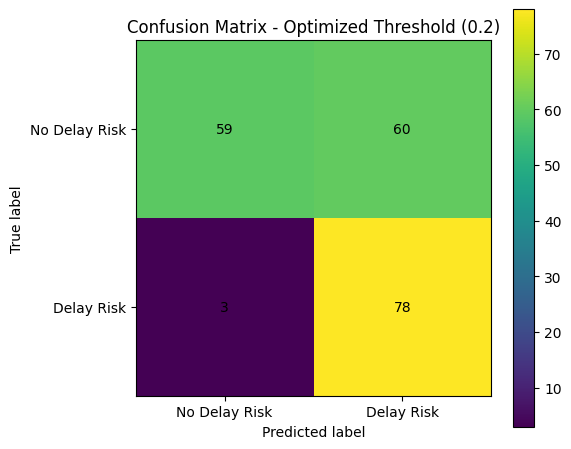

In [46]:
# Confusion matrix with optimized threshold
cm_optimized = confusion_matrix(y_test, y_pred_optimized)

plt.figure(figsize=(6, 5))
plt.imshow(cm_optimized)

plt.title(f"Confusion Matrix - Optimized Threshold ({best_threshold})")
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.xticks([0, 1], ["No Delay Risk", "Delay Risk"])
plt.yticks([0, 1], ["No Delay Risk", "Delay Risk"])

for i in range(cm_optimized.shape[0]):
    for j in range(cm_optimized.shape[1]):
        plt.text(j, i, cm_optimized[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()

plt.savefig("../figures/confusion_matrix_optimized.png")
plt.show()

## 34. Threshold Optimization Summary

The optimized threshold selected based on F1-score is 0.20.

With the default threshold of 0.50, the model correctly detected 52 delay-risk projects and missed 29 risky projects.

After threshold optimization, the model correctly detects 78 delay-risk projects and misses only 3 risky projects.

This means that the optimized threshold significantly improves the model's ability to identify projects at risk of delay. The recall for the delay-risk class increases from 64% to 96%.

However, this improvement comes with a trade-off. The model also generates more false alarms: 60 non-risky projects are classified as risky. This reduces precision and slightly decreases the overall accuracy.

In a construction project management context, this trade-off can be acceptable. It is often better to flag more projects for monitoring than to miss projects that may experience serious delays, cost overruns or operational issues.

Therefore, the optimized threshold can be interpreted as an early-warning strategy for project managers. It helps identify projects that require closer monitoring and preventive actions.

## Business-Oriented Threshold Choice

Although the threshold of 0.20 gives the highest F1-score, it also generates many false alerts.

For operational use in construction project monitoring, too many false alerts may overload project managers and reduce the usefulness of the system.

A threshold of 0.35 provides a better business compromise. It maintains a relatively high recall for delay-risk projects while improving precision and reducing false alerts compared to the 0.20 threshold.

Therefore, the threshold of 0.35 is selected as the recommended business-oriented threshold.

This threshold supports a balanced early-warning system: it detects a large proportion of risky projects while keeping the number of unnecessary alerts more manageable.

In [47]:
# Select business-oriented threshold
business_threshold = 0.35

# Predictions using business-oriented threshold
y_pred_business = (y_proba_best >= business_threshold).astype(int)

print("Business-oriented threshold:", business_threshold)

print("\nClassification Report with Business-Oriented Threshold")
print(classification_report(
    y_test,
    y_pred_business,
    target_names=["No Delay Risk", "Delay Risk"]
))

Business-oriented threshold: 0.35

Classification Report with Business-Oriented Threshold
               precision    recall  f1-score   support

No Delay Risk       0.81      0.68      0.74       119
   Delay Risk       0.62      0.77      0.69        81

     accuracy                           0.71       200
    macro avg       0.72      0.72      0.71       200
 weighted avg       0.73      0.71      0.72       200



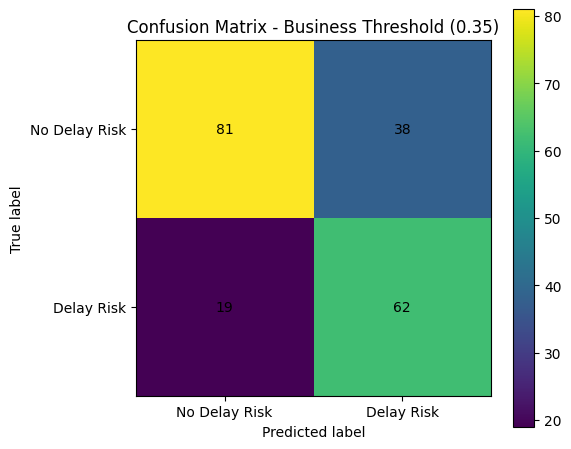

In [48]:
# Confusion matrix with business-oriented threshold
cm_business = confusion_matrix(y_test, y_pred_business)

plt.figure(figsize=(6, 5))
plt.imshow(cm_business)

plt.title(f"Confusion Matrix - Business Threshold ({business_threshold})")
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.xticks([0, 1], ["No Delay Risk", "Delay Risk"])
plt.yticks([0, 1], ["No Delay Risk", "Delay Risk"])

for i in range(cm_business.shape[0]):
    for j in range(cm_business.shape[1]):
        plt.text(j, i, cm_business[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()

plt.savefig("../figures/confusion_matrix_business_threshold.png")
plt.show()

## 35. Advanced Model Improvement with Feature Engineering

Threshold optimization changes the decision rule, but it does not improve the model's ability to separate risky and non-risky projects.

To improve the predictive power of the model, this section introduces additional business-oriented features inspired by construction project management.

These engineered features are designed to capture operational risk signals such as cost overrun, low resource availability, supplier delays, project complexity and low progress.

After creating these new features, the machine learning models are trained again and compared with the initial results.

In [49]:
# Create a new dataset with engineered features
data_improved = data.copy()

# Cost overrun indicator
data_improved["Cost_Overrun_Flag"] = np.where(
    data_improved["Cost_Used_Percent"] > 100,
    "Yes",
    "No"
)

# Low material or equipment availability
data_improved["Low_Resource_Availability"] = np.where(
    (data_improved["Material_Availability"] == "Low") |
    (data_improved["Equipment_Availability"] == "Low"),
    "Yes",
    "No"
)

# High operational risk indicator
data_improved["High_Operational_Risk"] = np.where(
    (data_improved["Supplier_Delay"] == "Yes") |
    (data_improved["Weather_Risk"] == "High") |
    (data_improved["Project_Complexity"] == "High"),
    "Yes",
    "No"
)

# Progress delay indicator
data_improved["Low_Progress_Flag"] = np.where(
    data_improved["Project_Progress_Percent"] < 40,
    "Yes",
    "No"
)

# Safety risk indicator
data_improved["High_Safety_Risk"] = np.where(
    data_improved["Safety_Incidents"] >= 3,
    "Yes",
    "No"
)

# Display new columns
data_improved[
    [
        "Cost_Overrun_Flag",
        "Low_Resource_Availability",
        "High_Operational_Risk",
        "Low_Progress_Flag",
        "High_Safety_Risk"
    ]
].head()

,Cost_Overrun_Flag,Low_Resource_Availability,High_Operational_Risk,Low_Progress_Flag,High_Safety_Risk
0,No,No,No,No,No
1,No,Yes,No,No,No
2,Yes,No,Yes,No,No
3,No,No,Yes,No,No
4,No,Yes,No,Yes,No


## 36. Preparing Improved Dataset for Machine Learning

The improved dataset includes the original variables plus additional engineered features.

The same preprocessing and train-test split approach is applied to ensure a fair comparison with the initial models.

In [50]:
# Encode target variable
data_improved["Delay_Risk"] = data_improved["Delay_Risk"].map({
    "No": 0,
    "Yes": 1
})

# Define features and target
X_improved = data_improved.drop(columns=["Project_ID", "Delay_Risk"])
y_improved = data_improved["Delay_Risk"]

# Identify numerical and categorical features
numerical_features_improved = X_improved.select_dtypes(
    include=["int64", "int32", "float64"]
).columns.tolist()

categorical_features_improved = X_improved.select_dtypes(
    include=["object"]
).columns.tolist()

print("Shape of improved X:", X_improved.shape)
print("Shape of improved y:", y_improved.shape)

print("\nNumerical features:")
print(numerical_features_improved)

print("\nCategorical features:")
print(categorical_features_improved)

Shape of improved X: (1000, 18)
Shape of improved y: (1000,)

Numerical features:
['Planned_Duration_Months', 'Project_Progress_Percent', 'Budget_Million_DZD', 'Cost_Used_Percent', 'Number_of_Workers', 'Safety_Incidents']

Categorical features:
['Project_Type', 'Region', 'Material_Availability', 'Equipment_Availability', 'Weather_Risk', 'Supplier_Delay', 'Project_Complexity', 'Cost_Overrun_Flag', 'Low_Resource_Availability', 'High_Operational_Risk', 'Low_Progress_Flag', 'High_Safety_Risk']


In [51]:
# Train-test split for improved dataset
X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
    X_improved,
    y_improved,
    test_size=0.2,
    random_state=42,
    stratify=y_improved
)

# Improved preprocessing pipeline
preprocessor_improved = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features_improved),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_improved)
    ]
)

print("Improved preprocessing pipeline created successfully")

Improved preprocessing pipeline created successfully


## 37. Training Models on the Improved Dataset

The same models are trained again using the improved dataset.

The objective is to check whether business-oriented feature engineering improves model performance.

In [52]:
# Define models for improved dataset
improved_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Logistic Regression Balanced": LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        class_weight="balanced"
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

improved_results = []
improved_trained_models = {}

for model_name, model in improved_models.items():
    
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor_improved),
            ("model", model)
        ]
    )
    
    pipeline.fit(X_train_imp, y_train_imp)
    
    y_pred_imp = pipeline.predict(X_test_imp)
    y_proba_imp = pipeline.predict_proba(X_test_imp)[:, 1]
    
    improved_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test_imp, y_pred_imp),
        "Precision": precision_score(y_test_imp, y_pred_imp),
        "Recall": recall_score(y_test_imp, y_pred_imp),
        "F1-score": f1_score(y_test_imp, y_pred_imp),
        "ROC-AUC": roc_auc_score(y_test_imp, y_proba_imp)
    })
    
    improved_trained_models[model_name] = pipeline

improved_results_df = pd.DataFrame(improved_results)
improved_results_df = improved_results_df.sort_values(by="ROC-AUC", ascending=False)

improved_results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.755,0.700000,0.691358,0.695652,0.841996
1,Logistic Regression Balanced,0.760,0.677419,0.777778,0.724138,0.841685
2,Random Forest,0.730,0.690141,0.604938,0.644737,0.812325
3,Gradient Boosting,0.715,0.666667,0.592593,0.627451,0.786907


## 38. Improved Model Results Summary

The feature engineering step improved the overall predictive performance of the models.

Compared to the initial Logistic Regression model, the improved Logistic Regression models achieved higher ROC-AUC, F1-score and recall.

The best business-oriented model is the Logistic Regression Balanced model. Although its precision is slightly lower than the standard Logistic Regression model, it provides a higher recall for delay-risk projects.

In a construction project management context, this is important because detecting risky projects early is more valuable than only maximizing global accuracy.

Therefore, the Logistic Regression Balanced model is selected as the final model.

## 39. Final Model Selection

After applying feature engineering, the Logistic Regression Balanced model was selected as the final model.

This model provides the best business-oriented trade-off between accuracy, recall, F1-score and ROC-AUC.

In construction project monitoring, recall is particularly important because the objective is to detect projects that are likely to experience delays. Missing a risky project can lead to cost overruns, operational issues and planning difficulties.

The final model achieves a ROC-AUC score of approximately 0.84 and a recall of approximately 0.78 for the delay-risk class, which indicates a good ability to identify risky projects while maintaining a reasonable level of precision.

In [53]:
# Select final model
final_model_name = "Logistic Regression Balanced"
final_model = improved_trained_models[final_model_name]

# Generate predictions
y_pred_final = final_model.predict(X_test_imp)
y_proba_final = final_model.predict_proba(X_test_imp)[:, 1]

print("Final selected model:", final_model_name)

Final selected model: Logistic Regression Balanced


## 40. Final Classification Report

The classification report evaluates the final model using precision, recall and F1-score for each class.

Special attention is given to the `Delay Risk` class because the main objective is to detect projects that may experience delays.

In [54]:
print(f"Classification Report for {final_model_name}")

print(classification_report(
    y_test_imp,
    y_pred_final,
    target_names=["No Delay Risk", "Delay Risk"]
))

Classification Report for Logistic Regression Balanced
               precision    recall  f1-score   support

No Delay Risk       0.83      0.75      0.79       119
   Delay Risk       0.68      0.78      0.72        81

     accuracy                           0.76       200
    macro avg       0.75      0.76      0.76       200
 weighted avg       0.77      0.76      0.76       200



## 41. Final Confusion Matrix

The confusion matrix shows how many projects were correctly and incorrectly classified by the final improved model.

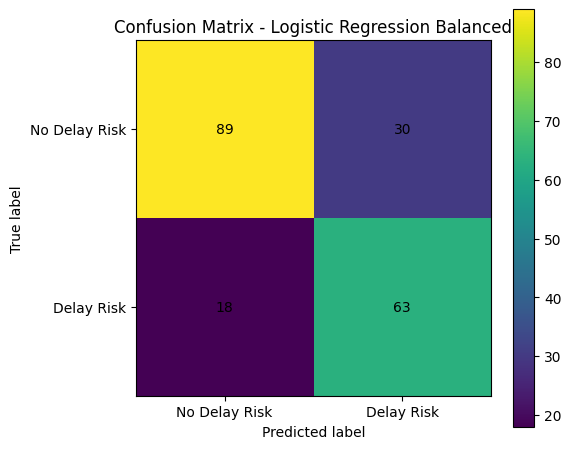

In [55]:
# Final confusion matrix
cm_final = confusion_matrix(y_test_imp, y_pred_final)

plt.figure(figsize=(6, 5))
plt.imshow(cm_final)

plt.title(f"Confusion Matrix - {final_model_name}")
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.xticks([0, 1], ["No Delay Risk", "Delay Risk"])
plt.yticks([0, 1], ["No Delay Risk", "Delay Risk"])

for i in range(cm_final.shape[0]):
    for j in range(cm_final.shape[1]):
        plt.text(j, i, cm_final[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()

plt.savefig("../figures/confusion_matrix_final_model.png")
plt.show()

## 42. Final ROC Curve

The ROC curve evaluates the ability of the final model to distinguish between projects with delay risk and projects without delay risk.

A ROC-AUC score closer to 1 indicates better discrimination performance.

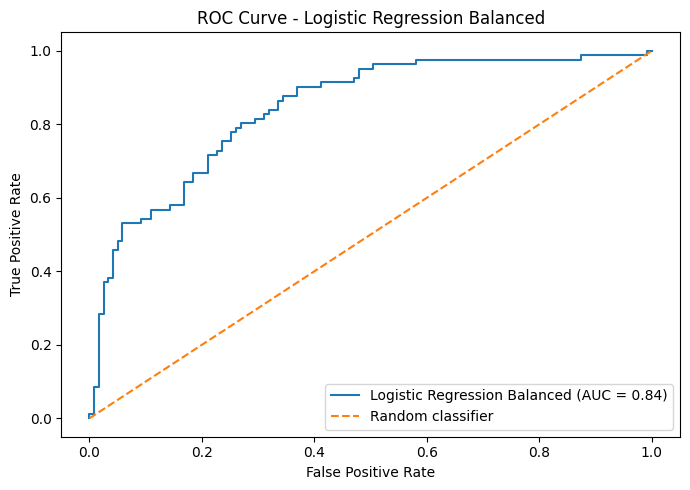

In [56]:
# Final ROC curve
fpr_final, tpr_final, thresholds_final = roc_curve(y_test_imp, y_proba_final)
roc_auc_final = auc(fpr_final, tpr_final)

plt.figure(figsize=(7, 5))
plt.plot(fpr_final, tpr_final, label=f"{final_model_name} (AUC = {roc_auc_final:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")

plt.title(f"ROC Curve - {final_model_name}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()

plt.savefig("../figures/roc_curve_final_model.png")
plt.show()

## 43. Final Model Evaluation Summary

The final selected model is the Logistic Regression Balanced model trained on the improved dataset.

The model achieves an accuracy of 76% and a ROC-AUC score of 0.84, which indicates a good ability to distinguish between projects with delay risk and projects without delay risk.

For the delay-risk class, the model achieves a recall of 78% and an F1-score of 72%. This means that the model is able to detect a large proportion of risky projects while maintaining a reasonable level of precision.

The confusion matrix shows that the model correctly detects 63 delay-risk projects out of 81, while 18 risky projects are not detected. In a construction management context, this result is useful because early detection of risky projects can help project managers take preventive actions before delays become critical.

Compared to the initial baseline model, the improved model provides better recall, F1-score and ROC-AUC. This confirms that the feature engineering step improved the predictive performance and business relevance of the model.

## 44. Feature Importance of the Final Model

This section analyzes the most influential variables in the final Logistic Regression Balanced model.

For Logistic Regression, the importance of each feature can be interpreted using the model coefficients.

A positive coefficient increases the probability of delay risk, while a negative coefficient decreases the probability of delay risk.

Because categorical variables are transformed using one-hot encoding, each category receives its own coefficient.

In [57]:
# Extract feature names after preprocessing
feature_names_final = final_model.named_steps["preprocessor"].get_feature_names_out()

# Extract coefficients from Logistic Regression
coefficients_final = final_model.named_steps["model"].coef_[0]

# Create feature importance dataframe
feature_importance_final = pd.DataFrame({
    "Feature": feature_names_final,
    "Coefficient": coefficients_final
})

# Add absolute coefficient for ranking
feature_importance_final["Absolute_Coefficient"] = feature_importance_final["Coefficient"].abs()

# Sort by absolute importance
feature_importance_final = feature_importance_final.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

feature_importance_final.head(20)

,Feature,Coefficient,Absolute_Coefficient
25,cat__Material_Availability_Low,1.112998,1.112998
24,cat__Material_Availability_High,-0.877030,0.877030
30,cat__Weather_Risk_High,0.780334,0.780334
28,cat__Equipment_Availability_Low,0.772100,0.772100
35,cat__Project_Complexity_High,0.712259,0.712259
34,cat__Supplier_Delay_Yes,0.682480,0.682480
33,cat__Supplier_Delay_No,-0.680236,0.680236
47,cat__High_Safety_Risk_Yes,0.648528,0.648528
46,cat__High_Safety_Risk_No,-0.646284,0.646284
45,cat__Low_Progress_Flag_Yes,0.596443,0.596443


## 45. Top Important Features Visualization

The following chart shows the top 20 most influential features of the final model.

The features are ranked according to the absolute value of their coefficients.

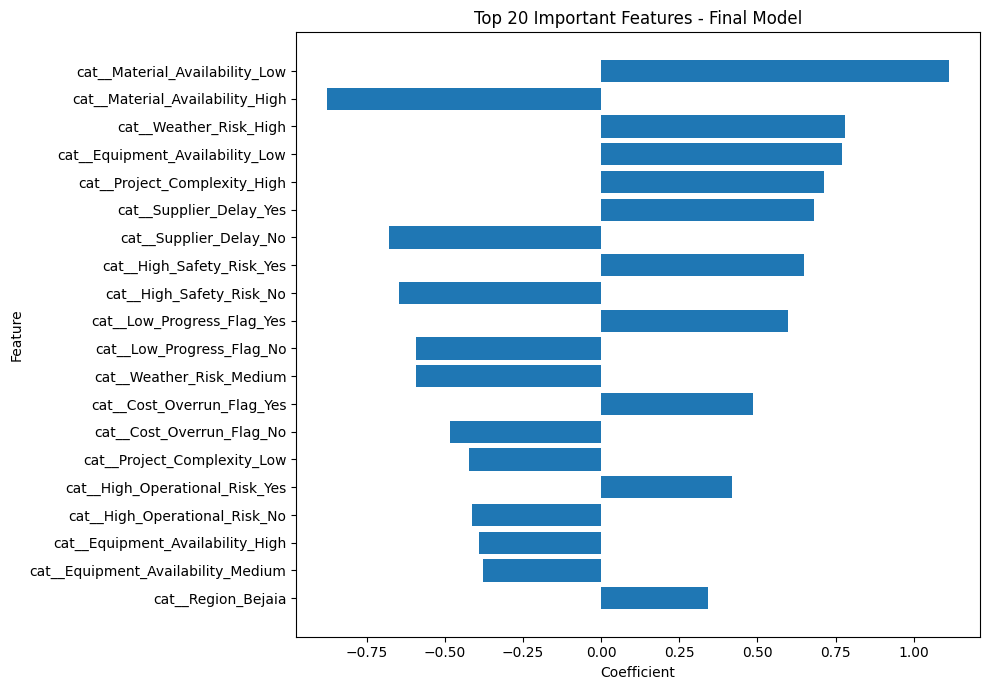

In [58]:
# Plot top 20 important features
top_features_final = feature_importance_final.head(20).copy()

plt.figure(figsize=(10, 7))
plt.barh(top_features_final["Feature"], top_features_final["Coefficient"])

plt.title("Top 20 Important Features - Final Model")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig("../figures/feature_importance_final_model.png")
plt.show()

## 46. Positive and Negative Drivers of Delay Risk

This section separates the main factors that increase delay risk from those that reduce delay risk.

In [59]:
# Features increasing delay risk
positive_drivers = feature_importance_final[
    feature_importance_final["Coefficient"] > 0
].head(10)

# Features decreasing delay risk
negative_drivers = feature_importance_final[
    feature_importance_final["Coefficient"] < 0
].head(10)

print("Top features increasing delay risk:")
display(positive_drivers[["Feature", "Coefficient"]])

print("\nTop features decreasing delay risk:")
display(negative_drivers[["Feature", "Coefficient"]])

Top features increasing delay risk:


,Feature,Coefficient
25,cat__Material_Availability_Low,1.112998
30,cat__Weather_Risk_High,0.780334
28,cat__Equipment_Availability_Low,0.772100
35,cat__Project_Complexity_High,0.712259
34,cat__Supplier_Delay_Yes,0.682480
47,cat__High_Safety_Risk_Yes,0.648528
45,cat__Low_Progress_Flag_Yes,0.596443
39,cat__Cost_Overrun_Flag_Yes,0.486018
43,cat__High_Operational_Risk_Yes,0.417212
15,cat__Region_Bejaia,0.340497



Top features decreasing delay risk:


,Feature,Coefficient
24,cat__Material_Availability_High,-0.877030
33,cat__Supplier_Delay_No,-0.680236
46,cat__High_Safety_Risk_No,-0.646284
44,cat__Low_Progress_Flag_No,-0.594199
32,cat__Weather_Risk_Medium,-0.592887
38,cat__Cost_Overrun_Flag_No,-0.483774
36,cat__Project_Complexity_Low,-0.423586
42,cat__High_Operational_Risk_No,-0.414968
27,cat__Equipment_Availability_High,-0.390422
29,cat__Equipment_Availability_Medium,-0.379435


## 47. Saving Final Feature Importance Results

The final feature importance table is saved as a CSV file for documentation and GitHub presentation.

In [60]:
# Save final feature importance results
feature_importance_final.to_csv("../feature_importance_final.csv", index=False)

print("Final feature importance results saved successfully")

Final feature importance results saved successfully


## 48. Feature Importance Interpretation

The final model shows that the most important factors increasing construction project delay risk are low material availability, high weather risk, low equipment availability, high project complexity and supplier delays.

These results are consistent with real-world construction project management challenges. Projects are more likely to experience delays when materials are not available, equipment is insufficient, suppliers are late, weather conditions are difficult or the project is technically complex.

The engineered features also provide useful business insights. Cost overrun, low project progress and high safety risk contribute positively to delay risk. This confirms that budget consumption, execution progress and safety indicators can be useful early-warning signals.

On the other hand, high material availability, no supplier delay, no high safety risk, no cost overrun and high equipment availability reduce the probability of delay risk.

These findings can help construction companies prioritize monitoring actions and focus on the operational factors that have the strongest influence on project delays.


## 49. Business Recommendations

Based on the exploratory analysis, model evaluation and feature importance results, several business recommendations can be proposed for construction project monitoring.

### 1. Monitor material availability closely

Low material availability is the strongest factor increasing delay risk. Project managers should track material stock levels, delivery schedules and supplier reliability throughout the project lifecycle.

### 2. Improve equipment planning

Low equipment availability strongly increases delay risk. Construction companies should optimize equipment allocation, maintenance planning and machinery availability across projects.

### 3. Strengthen supplier monitoring

Projects with supplier delays show a much higher probability of delay. Supplier performance indicators should be monitored regularly, especially for critical materials and equipment.

### 4. Focus on complex projects

Highly complex projects are more exposed to delays. These projects should receive closer supervision, more detailed planning and stronger risk management processes.

### 5. Use budget consumption as an early-warning indicator

Projects with cost overruns are more likely to face delays. Monitoring the percentage of budget already used can help detect projects requiring corrective action.

### 6. Track project progress and safety incidents

Low project progress and high safety incidents are relevant risk signals. Project managers should combine progress monitoring with safety reporting to identify projects that may require intervention.

### 7. Use the model as a decision-support tool

The model should not replace project managers. Instead, it can be used as an early-warning system to identify projects that require closer monitoring and preventive actions.

## 50. Final Project Summary

This project developed a machine learning approach to predict delay risk in construction projects using a synthetic dataset inspired by real-world construction and public works challenges.

The analysis included data generation, exploratory data analysis, preprocessing, model training, model improvement, threshold analysis and feature importance interpretation.

The final selected model is the Logistic Regression Balanced model trained on the improved dataset with engineered business features.

The model achieved:

- Accuracy: 76%
- ROC-AUC: 0.84
- Recall for delay-risk projects: 78%
- F1-score for delay-risk projects: 72%

The results show that delay risk is mainly influenced by material availability, equipment availability, supplier delays, weather risk, project complexity, safety incidents, project progress and cost overrun.

This project demonstrates how data science can support construction project monitoring by helping identify projects that may require closer attention before delays become critical.